Not all optimizers are born equal. They come in many equations and complexities but one thing they have in common, they are all there to help you train your network. It does not matter if you are working on prediction, classification, or even segmentation task, they will always try to do their best!

Every optimizer has its own strong and weaker sides and every developer should be familiar with them. All the optimizers goal is the same, reduce the loss as much as possible in their own way by manipulating model parameters.

While there are many optimizers in the wild, in this notebook we will go over those which are implemented in Keras libraries.

### Optimizers background

All the optimizers have the same baseline where the gradients of the cost function are calculated through the entire model chain and then subtract those gradients from the model parameters. We subtract because we are trying to find the lowest point in the cost function plane and the gradients "point" up the slope. What is defining the optimizers is how they regularize the update process of the parameters as we will see later.

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT-zueD_MQZh2N6DU0NVJxuyMEVOcnOChPEryJdmnoPBVf09utd&s">


### SGD (Stochastic Gradient Descent)

First candidate for today is the GD (Gradient Descent) optimizer. There are actually three types of GDs and Keras implements all of them in one function. Let’s look on them.


#### BGD (Batch Gradient Descent))

The first type of GD is called BGD and it is the simplest optimizer to understand. But don’t let that mislead you as at large datasets he is the most computationally complex. That is because in BGD the entire detaset needs to be fed into the network to make only one "step". On top of that, in very large datasets there might not be enough RAM to hold the entire dataset. On the other hand, BGD theoretically will always aim to the lowest point in the loss function plane.

The equation for BGD takes the gradient of the cost function and subtracts it from the parameter. Usually a regularization hyper parameter is added called the "learning rate" to regulate the convergence. The "learning rate" is usually in the range of (1e-3, 1e-2). Below is the equation for BGD:

\begin{align}
\theta = \theta - \eta \cdot \nabla_\theta J( \theta)
\end{align}

* θ: parameter to update
* η: learning rate
* ∇<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.23em; padding-right: 0.071em;">θ</span>J(θ): derivative of cost function 


#### SGD (Stochastic Gradient Descent)

The second type is SGD which is the exact opposite from BGD. Here to take one "step" we compute only one example from the dataset so eventually in one epoch we will make steps as the number of examples in the dataset. This technique much faster than BGD and more practical as you don’t need to store the entire dataset in the RAM. Instead, the relevant data can be loaded at need. Those advantages come with a price as SGD suffers from high variance and the "steps" will not always be toward convergence. There is a way around this by carefully reducing the learning rate at each epoch. Doing so can improve SGD performance as much as being the same as BGD. Practically SGD is preferred over BGD for applications where the dataset is not small.

Below is the equation for SGD. the only difference from BGD is the derivative of the cost function uses only one example.

\begin{align}
\theta = \theta - \eta \cdot \nabla_\theta J( \theta; x^{(i)}; y^{(i)})
\end{align}


* θ: parameter to update
* η: learning rate
* ∇<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.23em; padding-right: 0.071em;">θ</span>J(θ; X<span class="mjx-sup" style="font-size: 70.7%; vertical-align: 0.513em; padding-left: 0px; padding-right: 0.071em;">(i)</span>; Y<span class="mjx-sup" style="font-size: 70.7%; vertical-align: 0.513em; padding-left: 0px; padding-right: 0.071em;">(i)</span>): derivative of cost function respect to one example
* X<span class="mjx-sup" style="font-size: 70.7%; vertical-align: 0.513em; padding-left: 0px; padding-right: 0.071em;">(i)</span>: features of example i
* Y<span class="mjx-sup" style="font-size: 70.7%; vertical-align: 0.513em; padding-left: 0px; padding-right: 0.071em;">(i)</span>: ground truth of example i


#### MBGD (Mini-Batch Gradient Descent))

The third type is MBGD and it is a compromise between SGD and BGD where we learn on a batch (several) of examples at every "step". Being a compromise, its variance is lower than SGD which makes it more stable. Practically, try to use power of 2 batch sizes as the ML frameworks are usually more optimized for them.

Below is the equation of MBGD and it is the same as SGD except the derivative depends on a batch of examples.

\begin{align}
\theta = \theta - \eta \cdot \nabla_\theta J( \theta; x^{(i:i+n)}; y^{(i:i+n)})
\end{align}

* θ: parameter to update
* η: learning rate
* ∇<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.23em; padding-right: 0.071em;">θ</span>J(θ; X<span class="mjx-sup" style="font-size: 70.7%; vertical-align: 0.513em; padding-left: 0px; padding-right: 0.071em;">(i)</span>; Y<span class="mjx-sup" style="font-size: 70.7%; vertical-align: 0.513em; padding-left: 0px; padding-right: 0.071em;">(i)</span>): derivative of cost function respect to several examples
* X<span class="mjx-sup" style="font-size: 70.7%; vertical-align: 0.513em; padding-left: 0px; padding-right: 0.071em;">(i:i+n)</span>: features of example i to n
* Y<span class="mjx-sup" style="font-size: 70.7%; vertical-align: 0.513em; padding-left: 0px; padding-right: 0.071em;">(i:i+n)</span>: ground truth of example i to n


#### GD Conclusion

In Keras you can control the batch size which gives you the option to turn the optimizer to BGD by setting batch size to the length of the data. Or make it SGD by setting batch size to 1. Or you can set batch size to any other number between 1 and dataset size to get MBGD. I would argue that this optimizer should be called MBGD with options to BGD and SGD to be less confusing. Nether less, Keras calls it SGD.


### Adagrad (Adaptive Gradient )

Adagrad differs from SGD by computing different learning rate for each parameter that changes every step. Let’s define g as the partial derivative with respect to θ:

\begin{align}
g_{t, i} = \nabla_\theta J( \theta_{t, i} )
\end{align}

Now looking on the Adagrads equation, it has two new parameters:

\begin{align}
\theta_{t+1, i} = \theta_{t, i} - \dfrac{\eta}{\sqrt{G_{t, ii} + \epsilon}} \cdot g_{t, i}
\end{align}

* G<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.212em; padding-right: 0.071em;">t</span>: sum of the squares of previous gradients
* ϵ: small number to eliminate division by zero (usually around 1e-8)

While Adagrad automatically reduces the learning rate differently for every parameter, it has a major drawback. By summing squares of gradients (which always be positive numbers), eventually will yield a large number that will make the gradient to "disappear" (be close to zero).

A more detailed explanation can be found in [1] and [2].


### Adadelta (ADAPTIVE LEARNING RATE METHOD)

Adadelta tries to solve Adagrad's drawbacks and it is a direct extension. Instead of summing all the past gradients, Adadelta restricts the number of past gradients on which it depends by calculating RMS on a running average. Let’s write all the Adadelta equations and then explain them:

\begin{align}
E[g^2]_t = \gamma E[g^2]_{t-1} + (1 - \gamma) g^2_t
\end{align}

\begin{align}
RMS[g]_{t} = \sqrt{E[g^2]_t + \epsilon}
\end{align}

\begin{align}
RMS[\Delta \theta]_{t} = \sqrt{E[\Delta \theta^2]_t + \epsilon}
\end{align}

\begin{align} 
\begin{split}
\Delta \theta_t &= - \dfrac{RMS[\Delta \theta]_{t-1}}{RMS[g]_{t}} g_{t} \\ 
\theta_{t+1} &= \theta_t + \Delta \theta_t 
\end{split} 
\end{align}

* E[g<span class="mjx-sup" style="font-size: 70.7%; vertical-align: 0.513em; padding-left: 0px; padding-right: 0.071em;">2</span>]<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.212em; padding-right: 0.071em;">t</span>: running average
* γ: decay constant. usually around 0.9

There are two main things that changed in the equations. First the denominator changed to the RMS over running mean that we mentioned before. Second is the numerator that changed from a learning rate constant to RMS over the previous parameter update vector. The numerator had to change because as the author of the paper said "acts as an acceleration term, accumulating previous gradients over a window of time".

One additional advantage of Adadelta is that there is no need to choose a learning rate.

A more detailed explenetion can be found in [1] and [3].


### RMSprop

The RMSprop is actually an unpublished algorithm. It was proposed in Coursera course [4] lecture [6]. The algorithm is an extension of Adagrad and very similar to Adadelta. RMSpror changes only the denominator to the same equation as Adadelta and setting γ=0.9:

\begin{align} 
\begin{split} 
E[g^2]_t &= 0.9 E[g^2]_{t-1} + 0.1 g^2_t \\ 
\theta_{t+1} &= \theta_{t} - \dfrac{\eta}{\sqrt{E[g^2]_t + \epsilon}} g_{t} 
\end{split} 
\end{align}


### Adam (Adaptive Moment Estimation)

Adam optimizer is an extension of two optimizers, RMSpror and Momentum [7]. The Adam uses the Momentum to correct the first momentum and RMSprop to correct the second momentum.

\begin{align} 
\begin{split} 
m_t &= \beta_1 m_{t-1} + (1 - \beta_1) g_t \\ 
v_t &= \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 
\end{split} 
\end{align}

* m<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.212em; padding-right: 0.071em;">t</span>: exponentially decaying average (first momentum)
* v<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.212em; padding-right: 0.071em;">t</span>: exponentially decaying average of past squared gradients (second momentum)

At initialization stage m<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.212em; padding-right: 0.071em;">t</span> and v<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.212em; padding-right: 0.071em;">t</span> should be initialized to zero vectors. This initialization creates a problem of biasing the gradient to zero. To overcome this problem, the author adds bias correction equations:

\begin{align} 
\begin{split} 
\hat{m}_t &= \dfrac{m_t}{1 - \beta^t_1} \\ 
\hat{v}_t &= \dfrac{v_t}{1 - \beta^t_2} 
\end{split} 
\end{align}

Finally, to update the parameters we use the following equation:

\begin{align} 
\theta_{t+1} = \theta_{t} - \dfrac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t
\end{align}

The author suggests to use the following hyper parameter values:
* β<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.212em; padding-right: 0.071em;">1</span> = 0.9
* β<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.212em; padding-right: 0.071em;">2</span> = 0.999
* γ = 1e-8

Adam is one of the most used optimizers in ML as it is stable and usually produces the best results.

A more detailed explanation can be found in [1], [5], and [7]


### AdaMax

While Adam uses l<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.212em; padding-right: 0.071em;">2</span> norm to calculate v<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.212em; padding-right: 0.071em;">t</span>, Adamax uses l<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.212em; padding-right: 0.071em;">∞</span>. This has two inpacts on the equetion. First one beeing that we dont need the bias correction terms. The second is that we v<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.212em; padding-right: 0.071em;">t</span> equation changes from l<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.212em; padding-right: 0.071em;">2</span> to l<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.212em; padding-right: 0.071em;">∞</span> norm (to not get confused, we will call the new parameter u instead of v):

\begin{align} 
\begin{split} 
m_t &= \beta_1 m_{t-1} + (1 - \beta_1) g_t
\end{split} 
\end{align}

\begin{align} 
\begin{split} 
u_t &= \beta_2^\infty v_{t-1} + (1 - \beta_2^\infty) |g_t|^\infty & = \max(\beta_2 \cdot v_{t-1}, |g_t|) \\
\end{split} 
\end{align}

\begin{align} 
\theta_{t+1} = \theta_{t} - \dfrac{\eta}{u_t} \hat{m}_t
\end{align}

Like previously, the author suggests to use the following hyper parameter values:
* β<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.212em; padding-right: 0.071em;">1</span> = 0.9
* β<span class="mjx-sub" style="font-size: 70.7%; vertical-align: -0.212em; padding-right: 0.071em;">2</span> = 0.999
* η = 2e-3

### Nadam (Nesterov-accelerated Adaptive Moment Estimation)

Last but not least, Nadam is Adam with NAG [1]. This makes the Nadam optimizer do two steps every time, one in the direction of the previous gradient and then in the direction in the new gradient. This adds a short memory to the system and reduces oscillation that might accur in the training process.

After equation manipulation we get the Nadam equations:

\begin{align} 
\begin{split} 
\hat{m}_t &= \dfrac{m_t}{1 - \beta^t_1} \\ 
\hat{v}_t &= \dfrac{v_t}{1 - \beta^t_2} \end{split} 
\end{align}

\begin{align} 
\theta_{t+1} = \theta_{t} - \dfrac{\eta}{\sqrt{\hat{v}_t} + \epsilon} (\beta_1 \hat{m}_t + \dfrac{(1 - \beta_1) g_t}{1 - \beta^t_1})
\end{align}


## Import libraries

In [1]:
import time
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, Input, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import model_from_json

In [2]:
# random seed
seed = 33
np.random.RandomState(seed)

# validation to training split ration
valid_size = 0.1

# use data augmentation i nthe first part of training
to_augment = False

## Load and prepare data

The competition contains four files:

* train.csv - the training set
* test.csv - the test set
* sample_submission.csv - a sample submission file in the correct format
* Dig-MNIST.csv - an additional labeled set of characters that can be used to validate or test model results before submitting to the leaderboard

We will use the train.csv for model training and validation, Dig-MNIST.csv to evaluate model performances, and we will make predictions and submit results from test.csv data. sample_submission.csv will be used as a template for our submission.

#### Set paths

In [3]:
data_path = '../input/Kannada-MNIST/'

train_path = data_path + 'train.csv'
test_path = data_path + 'test.csv'
dig_path = data_path + 'Dig-MNIST.csv'
sample_path = data_path + 'sample_submission.csv'

save_path = ''
load_path = '../input/kennada-mnist-pretrained-model/'

#### Load datasets

In [4]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
dig_df = pd.read_csv(dig_path)
sample_df = pd.read_csv(sample_path)

#### Preprocess data

In [5]:
# convert dataframes to numpy matricies
X = train_df.drop('label', axis=1).to_numpy()
y = train_df['label'].to_numpy()
X_dig = dig_df.drop('label', axis=1).to_numpy()
y_dig = dig_df['label'].to_numpy()
X_test = test_df.drop('id', axis=1).to_numpy()

# reshape X's for keras and encode y using one-hot-vector-encoding
X = X.reshape(-1, 28, 28, 1)
y = to_categorical(y)
X_dig = X_dig.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# normalize the data to range(0, 1)
X = X / 255
X_dig = X_dig / 255
X_test = X_test / 255

print('X shape is {}'.format(X.shape))
print('y shape is {}'.format(y.shape))
print('X_dig shape is {}'.format(X_dig.shape))
print('y_dig shape is {}'.format(y_dig.shape))
print('X_test shape is {}'.format(X_test.shape))

X shape is (60000, 28, 28, 1)
y shape is (60000, 10)
X_dig shape is (10240, 28, 28, 1)
y_dig shape is (10240,)
X_test shape is (5000, 28, 28, 1)


Notice that we don’t need to encode y_dig because it is more convenient this way to compare results. Unlike y, that will be part of the model training and has to be encoded for Keras.

### Split to training and validation data

In [6]:
# split to train and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=valid_size, random_state=seed) 

print('X_train shape = {}'.format(X_train.shape))
print('Y_train shape = {}'.format(y_train.shape))
print('X_valid shape = {}'.format(X_valid.shape))
print('Y_valid shape = {}'.format(y_valid.shape))

X_train shape = (54000, 28, 28, 1)
Y_train shape = (54000, 10)
X_valid shape = (6000, 28, 28, 1)
Y_valid shape = (6000, 10)


## Build model

Let’s build a CNN model. But how do we choose the right one? Thankfully, the MNIST dataset and Kannada MNIST dataset are fairly similar so we can use the best model from [8] and try all the optimizers on it.

In [7]:
# model builder
def build_model(optimizer):
    model = Sequential()
    
    model.add(Conv2D(filters=32, kernel_size=(5,5), padding='Same', activation='relu', input_shape=(28,28,1)))
    model.add(Conv2D(filters=32, kernel_size=(5,5), padding='Same', activation='relu'))
    model.add(MaxPool2D(pool_size=(2,2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(filters=64, kernel_size=(3,3), padding='Same', activation='relu'))
    model.add(Conv2D(filters=64, kernel_size=(3,3), padding='Same', activation='relu'))
    model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))
    
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

In [8]:
# save model
def save_trained_model(model, save_path, optimizer):
    # serialize model to JSON
    model_json = model.to_json()
    with open('{}Kennada MNIST with {}.json'.format(save_path, optimizer), "w") as json_file:
        json_file.write(model_json)

    # serialize weights to HDF5
    model.save_weights('{}Kennada MNIST with {}.h5'.format(save_path, optimizer))

    
# load pretrained model
def load_trained_model(optimizers, optimizer, load_path):
    # load json and create model
    json_file = open('{}Kennada MNIST with {}.json'.format(load_path, optimizers[optimizer]), 'r')
    loaded_model_json = json_file.read()
    json_file.close()
    model = model_from_json(loaded_model_json)

    # load weights into new model
    model.load_weights('{}Kennada MNIST with {}.h5'.format(load_path, optimizers[optimizer]))
    
    # compile the model
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

In [9]:
def load_history(load_path, optimizer):
    history = pd.read_csv('{}Kennada MNIST with {}.csv'.format(load_path, optimizer))
    
    return history.to_dict('list')

def save_history(history, save_path, optimizer):
    hist_df = pd.DataFrame(history)
    hist_df.to_csv('{}Kennada MNIST with {}.csv'.format(save_path, optimizer), index=False)

## Train network

In [10]:
# integer or None. Number of samples per gradient update. If unspecified, batch_size will default to 32
batch_size = 1024
# integer. 0, 1, or 2. Verbosity mode. 0 = silent, 1 = progress bar, 2 = one line per epoch
verbose = 0
# integer. Number of epochs to train the model. An epoch is an iteration over the entire x and y data provided
epochs = 30

Define dictionaries of all Keras optimizers [9] and default learning rates.

In [11]:
# every optimizer has a name
optimizers = {
    'sgd':        'SGD',
    'rmsprop':    'RMSprop',
    'adagrad':    'Adagrad',
    'adadelta':   'Adadelta',
    'adam':       'Adam',
    'adamax':     'Adamax',
    'nadam':      'Nadam',
}

# and default learning rate
learning_rates = {
    'sgd':        1e-2,
    'rmsprop':    1e-3,
    'adagrad':    1e-2,
    'adadelta':   1.0,
    'adam':       1e-3,
    'adamax':     2e-3,
    'nadam':      2e-3,
}

In [12]:
# create learning rate decay callback borrowed from here: https://www.kaggle.com/cdeotte/25-million-images-0-99757-mnist
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', 
                                            patience=3, 
                                            verbose=0, 
                                            factor=0.5, 
                                            min_lr=0.00001)

# artificially increase training set
train_datagen = ImageDataGenerator(rescale=1.0,
                                   rotation_range=10,
                                   width_shift_range=0.25,
                                   height_shift_range=0.25,
                                   shear_range=0.1,
                                   zoom_range=0.25,
                                   horizontal_flip=False)

# artificially increase validation set
valid_datagen = ImageDataGenerator(rescale=1.0)

Finally, lets train the model with different optimizers and see the difference.

In [13]:
# prepare empty dictionaries
history = {}
model = {}

for n, optimizer in enumerate(optimizers):
    # build model for every optimizer
    model[optimizer] = build_model(optimizer)

    # measure training time
    start = time.time()

    # train model
    if to_augment:
        h = model[optimizer].fit_generator(train_datagen.flow(X_train, y_train, batch_size=batch_size),
                                           steps_per_epoch=100,
                                           epochs=epochs,
                                           validation_data=valid_datagen.flow(X_valid, y_valid),
                                           callbacks=[learning_rate_reduction],
                                           verbose=verbose)
    else:
        h = model[optimizer].fit(X_train,
                                 y_train,
                                 batch_size=batch_size,
                                 epochs=epochs,
                                 validation_data=(X_valid,y_valid),
                                 callbacks=[learning_rate_reduction],
                                 verbose=verbose)

    history[optimizer] = h.history

    # print results
    print("{0} Optimizer: ".format(optimizers[optimizer]))
    print("Epochs={0:d}, Train accuracy={1:.5f}, Validation accuracy={2:.5f}, Training time={3:.2f} minutes"
              .format(epochs, 
                      max(history[optimizer]['accuracy']), 
                      max(history[optimizer]['val_accuracy']), 
                      (time.time()-start)/60))

SGD Optimizer: 
Epochs=30, Train accuracy=0.95137, Validation accuracy=0.97300, Training time=0.96 minutes
RMSprop Optimizer: 
Epochs=30, Train accuracy=0.99889, Validation accuracy=0.99533, Training time=0.91 minutes
Adagrad Optimizer: 
Epochs=30, Train accuracy=0.98350, Validation accuracy=0.98633, Training time=0.90 minutes
Adadelta Optimizer: 
Epochs=30, Train accuracy=0.31902, Validation accuracy=0.64683, Training time=0.89 minutes
Adam Optimizer: 
Epochs=30, Train accuracy=0.99776, Validation accuracy=0.99400, Training time=0.89 minutes
Adamax Optimizer: 
Epochs=30, Train accuracy=0.99537, Validation accuracy=0.99350, Training time=0.88 minutes
Nadam Optimizer: 
Epochs=30, Train accuracy=0.99809, Validation accuracy=0.99517, Training time=0.94 minutes


In [14]:
# apply smoothing filter
def smoothing_filter(data, filter_n=3):
    # filter_n should be odd number
    # extend the end for better accuracy at the end
    data = np.concatenate((data, [data[-1]]*filter_n))
    
    # apply filter
    data = np.convolve(data, [1/filter_n]*filter_n)
    
    # remove filter delay and padding
    return data[int(np.ceil(filter_n/2)) : -filter_n]


# plot training accuracy helper function
def plot_training_accuracy(history, names, epochs, to_smooth=False, filter_n=3, styles=[':','-.','--','-',':','-.','--','-',':','-.','--','-']):
    # filter_n should be odd number
    plt.figure(figsize=(15, 5))
    
    for n, h in enumerate(history.values()):
        # get validation accuracy history
        val_acc = h['val_accuracy']
        
        # smooth on request
        if to_smooth:
            val_acc = smoothing_filter(val_acc, filter_n)
        
        # plot history
        plt.plot(val_acc, linestyle=styles[n])
    
    plt.title('Model validation accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(names, loc='upper left')
    axes = plt.gca()
    axes.set_ylim([0.99, 0.997])
    axes.set_xlim([0, epochs-1])

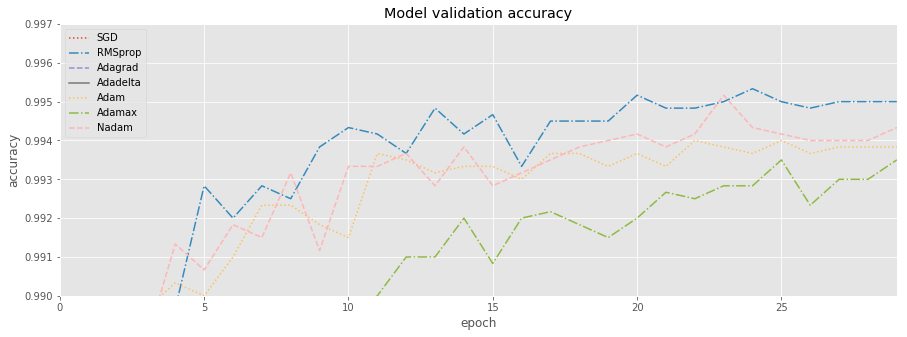

In [15]:
# plot learning hystory for all optimizers
plot_training_accuracy(history, optimizers.values(), epochs)

The graph is noisy and it is hard to pick optimizer like this. Let’s smooth the lines and plot again.

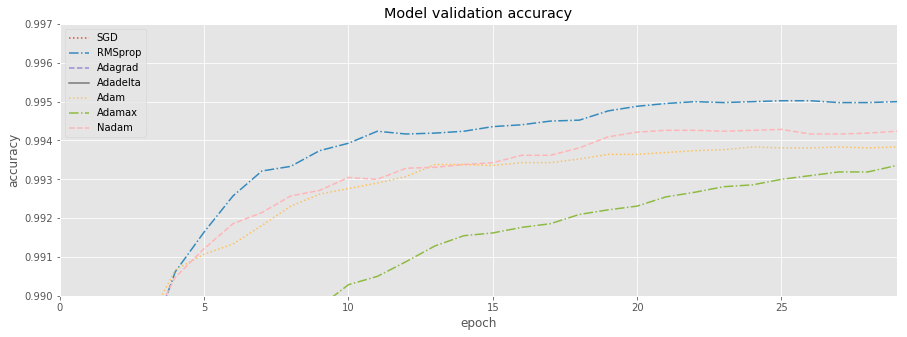

In [16]:
# filter_n should be odd number
filter_n = 7

# plot learning hystory for all optimizers
plot_training_accuracy(history, optimizers.values(), epochs, to_smooth=True, filter_n=filter_n)

In [17]:
# find optimizer with best score
def get_best_optimizer(history, optimizers, to_smooth=False, filter_n=3):
    # allocate memory
    best_val_scores = np.zeros((len(optimizers),))
    
    # find best score for each optimizer
    for n, h in enumerate(history.values()):
        # get validation accuracy history
        val_acc = h['val_accuracy']
        
        # smooth on request
        if to_smooth:
            val_acc = smoothing_filter(val_acc, filter_n)
        
        # find best val score
        best_val_scores[n] = np.max(val_acc)
    
    # returns best optimizers key as string
    return list(optimizers.keys())[np.argmax(best_val_scores)]

In [18]:
best_optimizer = get_best_optimizer(history, optimizers, to_smooth=True, filter_n=7)

print("Optimizer with best validation score is '{}'.".format(optimizers[best_optimizer]))

Optimizer with best validation score is 'RMSprop'.


Now, let’s train a new model on more epochs for better performance.

In [19]:
additional_epochs = 50

In [20]:
# save best model
filepath = save_path + 'best_model_with_'+ best_optimizer + '_on_' + str(additional_epochs) + '.hdf5'
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=0, save_best_only=True, mode='max')

# create new model
new_model = build_model(best_optimizer)

# measure training time
start = time.time()

# train model
new_history = new_model.fit_generator(train_datagen.flow(X_train, y_train, batch_size=batch_size),
                                      steps_per_epoch=100,
                                      epochs=additional_epochs,
                                      validation_data=valid_datagen.flow(X_valid, y_valid),
                                      callbacks=[learning_rate_reduction, checkpoint],
                                      verbose=verbose)
new_history = new_history.history

# print results
print("{0} Optimizer: ".format(optimizers[best_optimizer]))
print("Epochs={0:d}, Train accuracy={1:.5f}, Validation accuracy={2:.5f}, Training time={3:.2f} minutes"
          .format(additional_epochs, 
                  max(new_history['accuracy']), 
                  max(new_history['val_accuracy']), 
                  (time.time()-start)/60))

RMSprop Optimizer: 
Epochs=50, Train accuracy=0.99095, Validation accuracy=0.99667, Training time=28.77 minutes


## Check performance on Dig-MNIST data

In [21]:
# make predictions helper function
def make_prediction(model, x):
    y_pred = model.predict(x)
    return np.argmax(y_pred, axis=1)

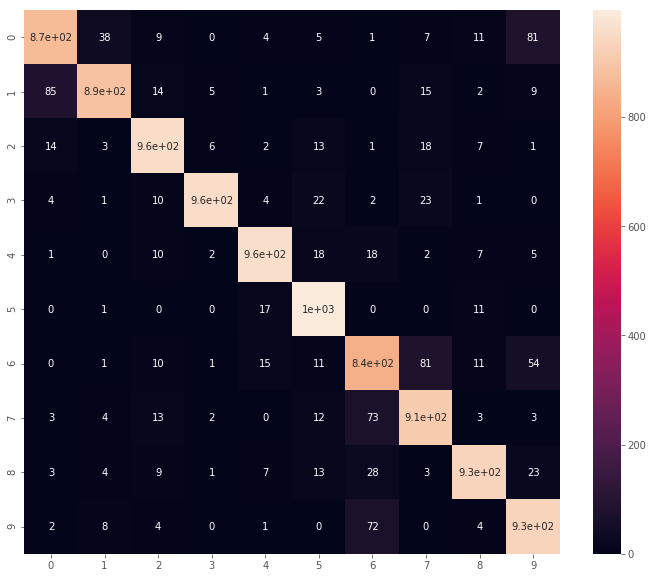

In [22]:
# predict on the Dig-MNIST set
y_pred = make_prediction(new_model, X_dig)

# build confusion matrix
conf = confusion_matrix(y_dig, y_pred)
conf = pd.DataFrame(conf, index=range(0,10), columns=range(0,10))

# plot the confusion matrix
plt.figure(figsize=(12,10))
sns.heatmap(conf, annot=True);

## Make submission file

Finally lets submit our predictions on the test dataset and see results.

In [23]:
# predict on the test set
y_result = make_prediction(new_model, X_test)

# save predictions
sample_df['label'] = y_result
sample_df.to_csv('submission.csv',index=False)

## Reference links

[1] <a href=https://ruder.io/optimizing-gradient-descent/> An overview of gradient descent optimization algorithms </a>

[2] <a href=https://medium.com/konvergen/an-introduction-to-adagrad-f130ae871827> An Introduction to AdaGrad </a>

[3] <a href=https://datascience.stackexchange.com/questions/27676/understanding-the-mathematics-of-adagrad-and-adadelta> Understanding the mathematics of AdaGrad and AdaDelta </a>

[4] <a href=https://www.coursera.org/learn/neural-networks-deep-learning> Neural Networks and Deep Learning </a>

[5] <a href=https://www.coursera.org/lecture/deep-neural-network/adam-optimization-algorithm-w9VCZ> Adam optimization algorithm </a>

[6] <a href=http://www.cs.toronto.edu/~tijmen/csc321/slides/lecture_slides_lec6.pdf> Overview of mini-batch gradient descent </a> page 29

[7] <a href=https://towardsdatascience.com/stochastic-gradient-descent-with-momentum-a84097641a5d> Stochastic Gradient Descent with momentum </a>

[8] <a href=https://www.kaggle.com/yassineghouzam/introduction-to-cnn-keras-0-997-top-6> Introduction to CNN Keras - Acc 0.997 (top 8%) </a>

[9] <a href=https://keras.io/optimizers/> Keras optimizers </a>